In [17]:
import os
print(os.getcwd())

f:\git_hub\customer-segmentation-app\notebook


In [18]:
#Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [19]:
print(os.listdir("../data"))

['Online Rentail.xlsx']


In [21]:
import pandas as pd

df = pd.read_excel("../data/Online Retail.xlsx", engine="openpyxl")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [22]:
#Step 3: Data Cleaning
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [23]:
#Step 4: RFM Calculation
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [24]:
#Step 5: Feature Scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

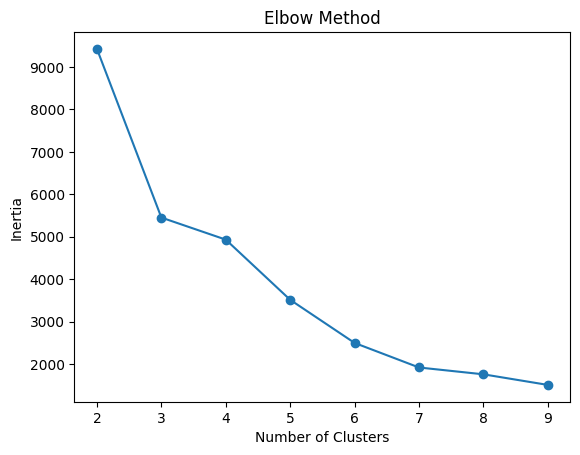

In [25]:
#Step 6: Elbow Method (Optimal K)
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [26]:
#Step 7: Silhouette Score
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.5766011709920204
K=3, Silhouette Score=0.6019775931686978
K=4, Silhouette Score=0.3588023011776161
K=5, Silhouette Score=0.3599790938322134
K=6, Silhouette Score=0.5133606176751524
K=7, Silhouette Score=0.5225734448733069
K=8, Silhouette Score=0.5244388648874353
K=9, Silhouette Score=0.504623773366762


In [27]:
#Step 8: Train K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

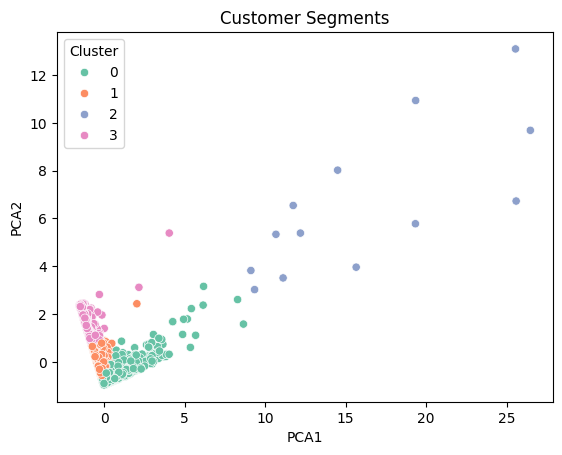

In [28]:
#Step 9: PCA Visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = pca_data[:, 0]
rfm['PCA2'] = pca_data[:, 1]

sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('Customer Segments')
plt.show()

In [29]:
#Step 10: Cluster Profiling
cluster_profile = rfm.groupby('Cluster').mean()
print(cluster_profile)

            Recency    Frequency       Monetary       PCA1      PCA2
Cluster                                                             
0         20.990788   135.285122    2645.818172   0.458467 -0.584719
1         98.218703    37.719457     773.877083  -0.269237 -0.046459
2          4.692308  2565.307692  126118.310000  16.201189  6.600735
3        272.407005    25.138889     605.842525  -1.025290  1.503888


In [30]:
#step 11: Assign Business Names
def segment(row):
    if row['Cluster'] == 0:
        return 'Champions'
    elif row['Cluster'] == 1:
        return 'At Risk'
    elif row['Cluster'] == 2:
        return 'Regular Customers'
    else:
        return 'Low Value'

rfm['Segment'] = rfm.apply(segment, axis=1)

In [31]:
#final output
rfm.head()

,Recency,Frequency,Monetary,Cluster,PCA1,PCA2,Segment
CustomerID,,,,,,,
12346.0,326,1,77183.60,3,4.035830,5.387646,Low Value
12347.0,2,182,4310.00,0,0.787446,-0.646318,Champions
12348.0,75,31,1797.24,1,-0.122907,-0.214699,At Risk
12349.0,19,73,1757.55,0,0.223759,-0.688905,Champions
12350.0,310,17,334.40,3,-1.220627,1.823920,Low Value


In [35]:
rfm_numeric = rfm[['Recency', 'Frequency', 'Monetary']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_numeric)

In [36]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [37]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
 3   Cluster    4338 non-null   int32  
 4   PCA1       4338 non-null   float64
 5   PCA2       4338 non-null   float64
 6   Segment    4338 non-null   object 
dtypes: float64(3), int32(1), int64(2), object(1)
memory usage: 254.2+ KB


In [38]:
rfm_numeric = rfm[['Recency', 'Frequency', 'Monetary']]
rfm_scaled = scaler.fit_transform(rfm_numeric)

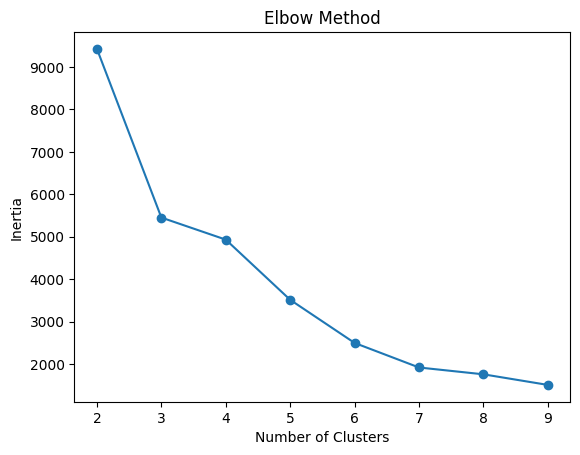

In [39]:
#STEP 2: Elbow Method (Find Best K)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [40]:
#STEP 3: Silhouette Score
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Score={score:.3f}")

K=2, Score=0.577
K=3, Score=0.602
K=4, Score=0.359
K=5, Score=0.360
K=6, Score=0.513
K=7, Score=0.523
K=8, Score=0.524
K=9, Score=0.505


In [41]:
#STEP 4: Train Final Model
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster,PCA1,PCA2,Segment
CustomerID,,,,,,,
12346.0,326,1,77183.60,3,4.035830,5.387646,Low Value
12347.0,2,182,4310.00,0,0.787446,-0.646318,Champions
12348.0,75,31,1797.24,1,-0.122907,-0.214699,At Risk
12349.0,19,73,1757.55,0,0.223759,-0.688905,Champions
12350.0,310,17,334.40,3,-1.220627,1.823920,Low Value


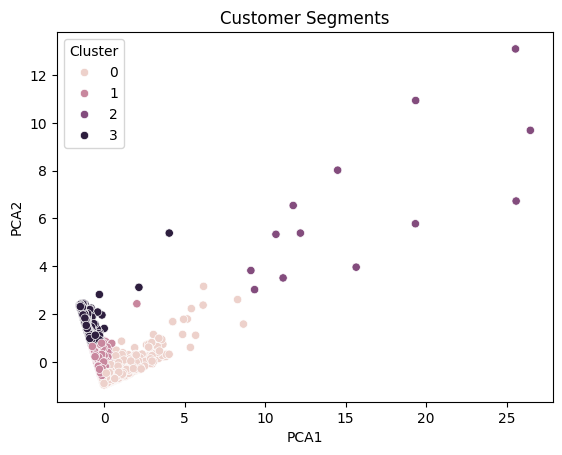

In [42]:
#STEP 5: PCA Visualization
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
pca_data = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = pca_data[:, 0]
rfm['PCA2'] = pca_data[:, 1]

sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster')
plt.title("Customer Segments")
plt.show()

In [44]:
#STEP 6: Cluster Profiling
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,20.990788,135.285122,2645.818172
1,98.218703,37.719457,773.877083
2,4.692308,2565.307692,126118.310000
3,272.407005,25.138889,605.842525


#both  are same 

In [46]:
#step 6.1
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
})

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,20.990788,135.285122,2645.818172
1,98.218703,37.719457,773.877083
2,4.692308,2565.307692,126118.310000
3,272.407005,25.138889,605.842525


In [48]:
#STEP 7: Segment Naming
def segment(row):
    if row['Cluster'] == 0:
        return 'Champions'
    elif row['Cluster'] == 1:
        return 'At Risk'
    elif row['Cluster'] == 2:
        return 'Regular'
    else:
        return 'Low Value'

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,Cluster,PCA1,PCA2,Segment
CustomerID,,,,,,,
12346.0,326,1,77183.60,3,4.035830,5.387646,Low Value
12347.0,2,182,4310.00,0,0.787446,-0.646318,Champions
12348.0,75,31,1797.24,1,-0.122907,-0.214699,At Risk
12349.0,19,73,1757.55,0,0.223759,-0.688905,Champions
12350.0,310,17,334.40,3,-1.220627,1.823920,Low Value
